<a href="https://colab.research.google.com/github/RaniellyPatricia/previsao-conversao-leads-cursos/blob/main/notebooks/04_modelagem_machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04 — Modelagem para previsão de conversão de leads

Este notebook tem como objetivo desenvolver e comparar modelos de Machine Learning capazes de prever a conversão de leads em cursos.

A variável-alvo é `convertido`, em que:

* `0` representa lead não convertido;
* `1` representa lead convertido.

A tarefa é de classificação binária.

Serão comparados três algoritmos:

1. Regressão Logística;
2. Árvore de Decisão;
3. Random Forest.

Os modelos serão avaliados por meio das métricas de acurácia, precisão, recall, F1-score, ROC-AUC e matriz de confusão.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
uploaded = files.upload()

Saving leads_tratados_mvp1 (2).csv to leads_tratados_mvp1 (2).csv


In [2]:
nome_arquivo = next(iter(uploaded))

df = pd.read_csv(nome_arquivo)

print(f"Arquivo carregado: {nome_arquivo}")
df.head()

Arquivo carregado: leads_tratados_mvp1 (2).csv


,id_do_prospect,numero_do_lead,origem_do_lead,fonte_do_lead,nao_enviar_e-mail,convertido,total_de_visitas,tempo_total_no_site,visualizacoes_de_pagina_por_visita,ultima_atividade,...,tags,qualidade_do_lead,perfil_do_lead,cidade,indice_de_atividade_assimetrica,indice_de_perfil_assimetrico,pontuacao_de_atividade_assimetrica,pontuacao_de_perfil_assimetrico,copia_gratuita_de_mastering_the_interview,ultima_atividade_relevante
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Chat Olark,Não,0,0.0,0,0.0,Página Visitada no Site,...,Interessado em outros cursos,Baixa Relevância,Não informado,Não informado,02.Médio,02.Médio,15.0,15.0,Não,Modificado
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Busca Orgânica,Não,0,5.0,674,2.5,E-mail Aberto,...,Chamando,Não informado,Não informado,Não informado,02.Médio,02.Médio,15.0,15.0,Não,E-mail Aberto
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Envio por Landing Page,Tráfego Direto,Não,1,2.0,1532,2.0,E-mail Aberto,...,Retornará após ler o e-mail,Talvez,Lead Potencial,Mumbai,02.Médio,01.Alto,14.0,20.0,Sim,E-mail Aberto
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Envio por Landing Page,Tráfego Direto,Não,0,1.0,305,1.0,Inalcançável,...,Chamando,Incerto,Não informado,Mumbai,02.Médio,01.Alto,13.0,17.0,Não,Modificado
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Envio por Landing Page,Google,Não,1,2.0,1428,1.0,Convertido em Lead,...,Retornará após ler o e-mail,Talvez,Não informado,Mumbai,02.Médio,01.Alto,15.0,18.0,Não,Modificado


In [3]:
print(f"Quantidade de linhas: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")
print(f"Valores nulos: {df.isnull().sum().sum()}")
print(f"Linhas duplicadas: {df.duplicated().sum()}")

print("\nDistribuição da variável-alvo:")
print(df["convertido"].value_counts())

print("\nDistribuição percentual:")
print(
    df["convertido"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Quantidade de linhas: 9240
Quantidade de colunas: 25
Valores nulos: 0
Linhas duplicadas: 0

Distribuição da variável-alvo:
convertido
0    5679
1    3561
Name: count, dtype: int64

Distribuição percentual:
convertido
0    61.46
1    38.54
Name: proportion, dtype: float64


## Seleção das variáveis

Nesta etapa, a variável-alvo será separada das variáveis preditoras.

Também serão removidas colunas identificadoras e variáveis com possível risco
de vazamento de dados. O objetivo é evitar que o modelo utilize informações
que não estariam disponíveis no momento real da previsão.

In [4]:
alvo = "convertido"

colunas_remover = [
    # Identificadores
    "id_do_prospect",
    "numero_do_lead",

    # Possível vazamento de dados
    "tags",
    "qualidade_do_lead",
    "perfil_do_lead",
    "ultima_atividade_relevante",

    # Pontuações criadas por processos anteriores
    "indice_de_atividade_assimetrica",
    "indice_de_perfil_assimetrico",
    "pontuacao_de_atividade_assimetrica",
    "pontuacao_de_perfil_assimetrico"
]

colunas_remover_existentes = [
    coluna
    for coluna in colunas_remover
    if coluna in df.columns
]

X = df.drop(
    columns=[alvo] + colunas_remover_existentes
)

y = df[alvo]

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

print("\nColunas removidas:")
for coluna in colunas_remover_existentes:
    print("-", coluna)

print("\nVariáveis mantidas para o modelo:")
for coluna in X.columns:
    print("-", coluna)

Formato de X: (9240, 14)
Formato de y: (9240,)

Colunas removidas:
- id_do_prospect
- numero_do_lead
- tags
- qualidade_do_lead
- perfil_do_lead
- ultima_atividade_relevante
- indice_de_atividade_assimetrica
- indice_de_perfil_assimetrico
- pontuacao_de_atividade_assimetrica
- pontuacao_de_perfil_assimetrico

Variáveis mantidas para o modelo:
- origem_do_lead
- fonte_do_lead
- nao_enviar_e-mail
- total_de_visitas
- tempo_total_no_site
- visualizacoes_de_pagina_por_visita
- ultima_atividade
- pais
- especializacao
- como_soube_da_x_education
- ocupacao_atual
- o_que_mais_importa_na_escolha_do_curso
- cidade
- copia_gratuita_de_mastering_the_interview


## Divisão dos dados em treino e teste

Os dados serão divididos em:

- 80% para treinamento dos modelos;
- 20% para teste.

A divisão será estratificada pela variável `convertido` para preservar a proporção de leads convertidos e não convertidos nos dois conjuntos.

In [5]:
from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X treino:", X_treino.shape)
print("X teste:", X_teste.shape)
print("y treino:", y_treino.shape)
print("y teste:", y_teste.shape)

print("\nProporção da variável-alvo no treino:")
print(y_treino.value_counts(normalize=True).round(4))

print("\nProporção da variável-alvo no teste:")
print(y_teste.value_counts(normalize=True).round(4))

X treino: (7392, 14)
X teste: (1848, 14)
y treino: (7392,)
y teste: (1848,)

Proporção da variável-alvo no treino:
convertido
0    0.6146
1    0.3854
Name: proportion, dtype: float64

Proporção da variável-alvo no teste:
convertido
0    0.6147
1    0.3853
Name: proportion, dtype: float64


## Preparação das variáveis

As variáveis foram separadas entre numéricas e categóricas.

As variáveis categóricas serão transformadas por meio do One-Hot Encoding,
que cria colunas binárias para representar cada categoria.

As variáveis numéricas serão padronizadas com StandardScaler, colocando-as
em uma escala comparável.

O pré-processamento será ajustado somente com os dados de treino, evitando
vazamento de informações do conjunto de teste.

In [6]:
colunas_numericas = X_treino.select_dtypes(
    include = ["int64", "float64"]).columns.tolist()

colunas_categoricas =  X_treino.select_dtypes(
    include = "object").columns.tolist()

print("Variáveis numéricas:")
for coluna in colunas_numericas:
  print("-", coluna)

print("\nVariáveis categóricas:")
for coluna in colunas_categoricas:
  print("-", coluna)

print("\nResumo:")
print(f"Quantidade de variáveis numéricas: {len(colunas_numericas)}")
print(f"Quantidade de variáveis categóricas: {len(colunas_categoricas)}")

Variáveis numéricas:
- total_de_visitas
- tempo_total_no_site
- visualizacoes_de_pagina_por_visita

Variáveis categóricas:
- origem_do_lead
- fonte_do_lead
- nao_enviar_e-mail
- ultima_atividade
- pais
- especializacao
- como_soube_da_x_education
- ocupacao_atual
- o_que_mais_importa_na_escolha_do_curso
- cidade
- copia_gratuita_de_mastering_the_interview

Resumo:
Quantidade de variáveis numéricas: 3
Quantidade de variáveis categóricas: 11


In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

processador = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), colunas_numericas),
        ("cat", OneHotEncoder(handle_unknown ="ignore"), colunas_categoricas)
    ]
)
print(processador)

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['total_de_visitas', 'tempo_total_no_site',
                                  'visualizacoes_de_pagina_por_visita']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['origem_do_lead', 'fonte_do_lead',
                                  'nao_enviar_e-mail', 'ultima_atividade',
                                  'pais', 'especializacao',
                                  'como_soube_da_x_education', 'ocupacao_atual',
                                  'o_que_mais_importa_na_escolha_do_curso',
                                  'cidade',
                                  'copia_gratuita_de_mastering_the_interview'])])


## Modelo 1 — Regressão Logística

A Regressão Logística será utilizada como primeiro modelo de classificação.

Ela estima a probabilidade de um lead pertencer à classe 1, ou seja, de realizar a conversão.

O pré-processamento e o modelo serão organizados em um Pipeline para garantir que as transformações sejam aplicadas corretamente aos dados de treino e teste.

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

modelo_logistico = Pipeline(
    steps=[
        ("preprocessamento", processador),
        ("modelo", LogisticRegression(max_iter = 1000,
                                      random_state=42))
    ]
)
modelo_logistico.fit(X_treino, y_treino)

print("V")


V


In [9]:
previsoes_logistica = modelo_logistico.predict(X_teste)

probabilidades_logistica = modelo_logistico.predict_proba(X_teste)[:, 1]

print("v")

v


In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

acuracia_logistica = accuracy_score(
    y_teste,
    previsoes_logistica
)

precisao_logistica = precision_score(
    y_teste,
    previsoes_logistica
)

recall_logistica = recall_score(
    y_teste,
    previsoes_logistica
)

f1_logistica = f1_score(
    y_teste,
    previsoes_logistica
)

roc_auc_logistica = roc_auc_score(
    y_teste,
    probabilidades_logistica
)

print(f"Acurácia: {acuracia_logistica:.4f}")
print(f"Precisão: {precisao_logistica:.4f}")
print(f"Recall: {recall_logistica:.4f}")
print(f"F1-score: {f1_logistica:.4f}")
print(f"ROC-AUC: {roc_auc_logistica:.4f}")

Acurácia: 0.7982
Precisão: 0.7564
Recall: 0.7022
F1-score: 0.7283
ROC-AUC: 0.8744


### Interpretação — Regressão Logística

A Regressão Logística apresentou acurácia de **79,82%**, indicando que o modelo classificou corretamente aproximadamente 8 em cada 10 leads do conjunto de teste.

A precisão foi de **75,64%**, o que significa que, entre os leads classificados pelo modelo como convertidos, aproximadamente 76% realmente realizaram a conversão.

O recall foi de **70,22%**, mostrando que o modelo conseguiu identificar cerca de 70% dos leads que realmente converteram. Isso também indica que aproximadamente 30% dos possíveis convertidos não foram identificados pelo modelo.

O F1-score foi de **72,83%**, demonstrando um equilíbrio razoável entre precisão e recall.

O ROC-AUC alcançou **87,44%**, indicando boa capacidade do modelo para diferenciar leads convertidos e não convertidos.

Esses resultados serão utilizados como referência para comparação com os modelos de Árvore de Decisão e Random Forest.


## Modelo 2 — Árvore de Decisão

A Árvore de Decisão realiza classificações por meio de regras sucessivas sobre
as características dos leads.

Foi definida uma profundidade máxima para reduzir o risco de o modelo memorizar
os dados de treinamento e apresentar baixo desempenho em novos registros.

In [11]:
from sklearn.tree import DecisionTreeClassifier

modelo_arvore = Pipeline(
    steps=[
        ("preprocessamento", processador),
        (
            "modelo",
            DecisionTreeClassifier(
                max_depth=5,
                min_samples_leaf=20,
                random_state=42
            )
        )
    ]
)

modelo_arvore.fit(X_treino, y_treino)

print("Árvore de Decisão treinada com sucesso.")

Árvore de Decisão treinada com sucesso.


In [12]:
previsoes_arvore = modelo_arvore.predict(X_teste)

probabilidades_arvore = modelo_arvore.predict_proba(
    X_teste
)[:, 1]

print("Previsões da Árvore de Decisão realizadas.")

Previsões da Árvore de Decisão realizadas.


In [13]:
acuracia_arvore = accuracy_score(
    y_teste,
    previsoes_arvore
)

precisao_arvore = precision_score(
    y_teste,
    previsoes_arvore
)

recall_arvore = recall_score(
    y_teste,
    previsoes_arvore
)

f1_arvore = f1_score(
    y_teste,
    previsoes_arvore
)

roc_auc_arvore = roc_auc_score(
    y_teste,
    probabilidades_arvore
)

print(f"Acurácia: {acuracia_arvore:.4f}")
print(f"Precisão: {precisao_arvore:.4f}")
print(f"Recall: {recall_arvore:.4f}")
print(f"F1-score: {f1_arvore:.4f}")
print(f"ROC-AUC: {roc_auc_arvore:.4f}")

Acurácia: 0.8139
Precisão: 0.7486
Recall: 0.7781
F1-score: 0.7631
ROC-AUC: 0.8629


### Interpretação — Árvore de Decisão

A Árvore de Decisão apresentou acurácia de 81,39%, superando a Regressão Logística nessa métrica.

A precisão foi de 74,86%, indicando que aproximadamente 75% dos leads classificados como convertidos realmente converteram.

O recall foi de 77,81%, mostrando que o modelo identificou a maior parte dos leads que realmente converteram. Esse resultado é relevante para o negócio, pois reduz a chance de perder leads com potencial de matrícula.

O F1-score foi de 76,31%, demonstrando melhor equilíbrio entre precisão e recall em comparação com a Regressão Logística.

O ROC-AUC foi de 86,29%, indicando boa capacidade de separação entre convertidos e não convertidos, embora ligeiramente inferior ao resultado da Regressão Logística.

## Modelo 3 — Random Forest

A Random Forest combina várias árvores de decisão para produzir uma classificação mais robusta.

O modelo reduz a dependência de uma única árvore e pode melhorar a capacidade de generalização para novos dados.

In [14]:
from sklearn.ensemble import RandomForestClassifier

modelo_random_forest = Pipeline(
    steps=[
        ("preprocessamento", processador),
        (
            "modelo",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=10,
                min_samples_leaf=10,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

modelo_random_forest.fit(X_treino, y_treino)

print("Random Forest treinada com sucesso.")

Random Forest treinada com sucesso.


In [15]:
previsoes_random_forest = modelo_random_forest.predict(X_teste)

probabilidades_random_forest = modelo_random_forest.predict_proba(
    X_teste
)[:, 1]

print("Previsões da Random Forest realizadas com sucesso.")

Previsões da Random Forest realizadas com sucesso.


In [16]:
acuracia_random_forest = accuracy_score(
    y_teste,
    previsoes_random_forest
)

precisao_random_forest = precision_score(
    y_teste,
    previsoes_random_forest
)

recall_random_forest = recall_score(
    y_teste,
    previsoes_random_forest
)

f1_random_forest = f1_score(
    y_teste,
    previsoes_random_forest
)

roc_auc_random_forest = roc_auc_score(
    y_teste,
    probabilidades_random_forest
)

print(f"Acurácia: {acuracia_random_forest:.4f}")
print(f"Precisão: {precisao_random_forest:.4f}")
print(f"Recall: {recall_random_forest:.4f}")
print(f"F1-score: {f1_random_forest:.4f}")
print(f"ROC-AUC: {roc_auc_random_forest:.4f}")

Acurácia: 0.8155
Precisão: 0.8026
Recall: 0.6910
F1-score: 0.7426
ROC-AUC: 0.8843


In [17]:
ranking_teste = df.loc[
    X_teste.index,
    ["id_do_prospect", "numero_do_lead"]
].copy()

ranking_teste["probabilidade_conversao"] = (
    probabilidades_random_forest
)

ranking_teste["probabilidade_percentual"] = (
    ranking_teste["probabilidade_conversao"] * 100
).round(2)

ranking_teste["previsao_modelo"] = previsoes_random_forest

ranking_teste = ranking_teste.sort_values(
    by="probabilidade_conversao",
    ascending=False
)

ranking_teste.head(20)

,id_do_prospect,numero_do_lead,probabilidade_conversao,probabilidade_percentual,previsao_modelo
5822,d5a9b668-ddad-4795-bf0e-a28390748a90,605216,0.960945,96.09,1
4788,6af21254-d8c1-4422-977f-487ae011cf65,614042,0.960945,96.09,1
4772,5e026ee7-1eb5-4836-b1d0-62069659751b,614103,0.960945,96.09,1
2681,5466f42c-df44-46f9-8bec-0a2e29dd33bc,633922,0.960945,96.09,1
2804,1b8b95eb-136c-4550-ae3e-4fa3533296f2,632816,0.960945,96.09,1
2680,1c67c1ec-e49b-4543-b05e-e039c536bcfd,633926,0.956077,95.61,1
8106,273692bc-01b6-4f3b-80df-7a0e83b366ab,587918,0.955485,95.55,1
8060,1f2d276d-b116-4e05-859b-0dff75c1dc22,588093,0.955485,95.55,1
5801,39fd64c1-3df6-43e4-9ff0-7ab5f8011009,605278,0.955309,95.53,1
446,c11cf85a-e78a-4a09-be7f-b02d197be200,655552,0.955309,95.53,1


In [18]:
ranking_teste["prioridade"] = pd.cut(
    ranking_teste["probabilidade_conversao"],
    bins=[-0.01, 0.40, 0.70, 1.00],
    labels=["Baixa", "Média", "Alta"]
)

ranking_teste.head(20)

,id_do_prospect,numero_do_lead,probabilidade_conversao,probabilidade_percentual,previsao_modelo,prioridade
5822,d5a9b668-ddad-4795-bf0e-a28390748a90,605216,0.960945,96.09,1,Alta
4788,6af21254-d8c1-4422-977f-487ae011cf65,614042,0.960945,96.09,1,Alta
4772,5e026ee7-1eb5-4836-b1d0-62069659751b,614103,0.960945,96.09,1,Alta
2681,5466f42c-df44-46f9-8bec-0a2e29dd33bc,633922,0.960945,96.09,1,Alta
2804,1b8b95eb-136c-4550-ae3e-4fa3533296f2,632816,0.960945,96.09,1,Alta
2680,1c67c1ec-e49b-4543-b05e-e039c536bcfd,633926,0.956077,95.61,1,Alta
8106,273692bc-01b6-4f3b-80df-7a0e83b366ab,587918,0.955485,95.55,1,Alta
8060,1f2d276d-b116-4e05-859b-0dff75c1dc22,588093,0.955485,95.55,1,Alta
5801,39fd64c1-3df6-43e4-9ff0-7ab5f8011009,605278,0.955309,95.53,1,Alta
446,c11cf85a-e78a-4a09-be7f-b02d197be200,655552,0.955309,95.53,1,Alta


In [19]:
def definir_acao(prioridade):
    if prioridade == "Alta":
        return "Contato comercial imediato"
    elif prioridade == "Média":
        return "Nutrição e acompanhamento"
    else:
        return "Fluxo automatizado"

ranking_teste["acao_sugerida"] = (
    ranking_teste["prioridade"]
    .astype(str)
    .apply(definir_acao)
)

ranking_teste.head(20)

,id_do_prospect,numero_do_lead,probabilidade_conversao,probabilidade_percentual,previsao_modelo,prioridade,acao_sugerida
5822,d5a9b668-ddad-4795-bf0e-a28390748a90,605216,0.960945,96.09,1,Alta,Contato comercial imediato
4788,6af21254-d8c1-4422-977f-487ae011cf65,614042,0.960945,96.09,1,Alta,Contato comercial imediato
4772,5e026ee7-1eb5-4836-b1d0-62069659751b,614103,0.960945,96.09,1,Alta,Contato comercial imediato
2681,5466f42c-df44-46f9-8bec-0a2e29dd33bc,633922,0.960945,96.09,1,Alta,Contato comercial imediato
2804,1b8b95eb-136c-4550-ae3e-4fa3533296f2,632816,0.960945,96.09,1,Alta,Contato comercial imediato
2680,1c67c1ec-e49b-4543-b05e-e039c536bcfd,633926,0.956077,95.61,1,Alta,Contato comercial imediato
8106,273692bc-01b6-4f3b-80df-7a0e83b366ab,587918,0.955485,95.55,1,Alta,Contato comercial imediato
8060,1f2d276d-b116-4e05-859b-0dff75c1dc22,588093,0.955485,95.55,1,Alta,Contato comercial imediato
5801,39fd64c1-3df6-43e4-9ff0-7ab5f8011009,605278,0.955309,95.53,1,Alta,Contato comercial imediato
446,c11cf85a-e78a-4a09-be7f-b02d197be200,655552,0.955309,95.53,1,Alta,Contato comercial imediato


In [20]:
ranking_teste.to_csv(
    "ranking_leads_teste.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Arquivo salvo com sucesso.")

Arquivo salvo com sucesso.


In [21]:
from google.colab import files

files.download("ranking_leads_teste.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
resultados_modelos = pd.DataFrame({
    "modelo": [
        "Regressão Logística",
        "Árvore de Decisão",
        "Random Forest"
    ],
    "acuracia": [
        acuracia_logistica,
        acuracia_arvore,
        acuracia_random_forest
    ],
    "precisao": [
        precisao_logistica,
        precisao_arvore,
        precisao_random_forest
    ],
    "recall": [
        recall_logistica,
        recall_arvore,
        recall_random_forest
    ],
    "f1_score": [
        f1_logistica,
        f1_arvore,
        f1_random_forest
    ],
    "roc_auc": [
        roc_auc_logistica,
        roc_auc_arvore,
        roc_auc_random_forest
    ]
})

resultados_modelos.sort_values(
    by="roc_auc",
    ascending=False
)

,modelo,acuracia,precisao,recall,f1_score,roc_auc
2,Random Forest,0.815476,0.802610,0.691011,0.742642,0.884350
0,Regressão Logística,0.798160,0.756430,0.702247,0.728332,0.874435
1,Árvore de Decisão,0.813853,0.748649,0.778090,0.763085,0.862915


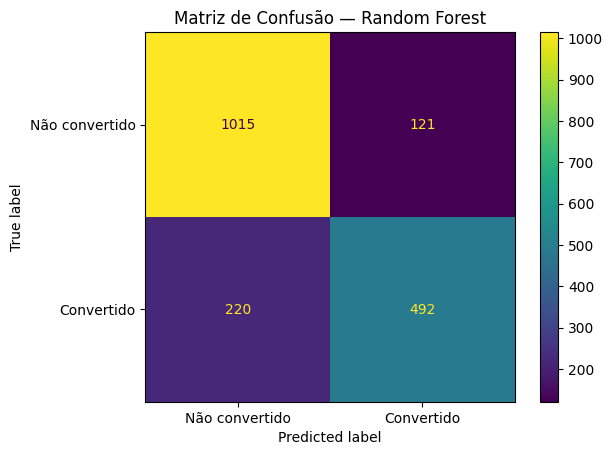

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_teste,
    previsoes_random_forest,
    display_labels=["Não convertido", "Convertido"],
    values_format="d"
)

plt.title("Matriz de Confusão — Random Forest")
plt.show()

In [24]:
ranking_teste["convertido_real"] = y_teste.loc[ranking_teste.index]

validacao_prioridade = (
    ranking_teste
    .groupby("prioridade")
    .agg(
        total_leads=("convertido_real", "count"),
        convertidos_reais=("convertido_real", "sum"),
        taxa_conversao_real=("convertido_real", "mean"),
        probabilidade_media=("probabilidade_conversao", "mean")
    )
    .reset_index()
)

validacao_prioridade["taxa_conversao_real"] = (
    validacao_prioridade["taxa_conversao_real"] * 100
).round(2)

validacao_prioridade["probabilidade_media"] = (
    validacao_prioridade["probabilidade_media"] * 100
).round(2)

validacao_prioridade

/tmp/ipykernel_1822/944678975.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("prioridade")


,prioridade,total_leads,convertidos_reais,taxa_conversao_real,probabilidade_media
0,Baixa,1056,141,13.35,19.80
1,Média,543,346,63.72,54.78
2,Alta,249,225,90.36,83.94


In [25]:
nomes_variaveis = (
    modelo_random_forest
    .named_steps["preprocessamento"]
    .get_feature_names_out()
)

importancias = (
    modelo_random_forest
    .named_steps["modelo"]
    .feature_importances_
)

tabela_importancias = pd.DataFrame({
    "variavel": nomes_variaveis,
    "importancia": importancias
})

tabela_importancias = tabela_importancias.sort_values(
    by="importancia",
    ascending=False
)

tabela_importancias.head(20)

,variavel,importancia
1,num__tempo_total_no_site,0.224213
40,cat__ultima_atividade_SMS Enviado,0.106637
6,cat__origem_do_lead_Formulário de Cadastro de ...,0.084503
115,cat__ocupacao_atual_Profissional Empregado,0.080533
113,cat__ocupacao_atual_Não informado,0.063490
118,cat__o_que_mais_importa_na_escolha_do_curso_Nã...,0.052086
117,cat__o_que_mais_importa_na_escolha_do_curso_Me...,0.050003
18,cat__fonte_do_lead_Referência,0.039180
109,cat__ocupacao_atual_Desempregado,0.031256
27,cat__ultima_atividade_Conversa no Chat Olark,0.024352


## Análise dos resultados do modelo

A Random Forest apresentou o melhor desempenho geral para o objetivo de priorização comercial, com acurácia de 0,8155, precisão de 0,8026 e ROC-AUC de 0,8843.

A matriz de confusão mostrou que o modelo classificou corretamente 1015 leads não convertidos e 492 leads convertidos. Também ocorreram 121 falsos positivos, ou seja, leads que foram previstos como convertidos, mas não converteram, e 220 falsos negativos, que representam leads convertidos que o modelo não conseguiu identificar.

Esse comportamento indica que a Random Forest é um modelo mais seletivo: ela evita indicar muitos leads ruins como oportunidades, mas pode deixar passar alguns leads que converteriam. Por isso, o modelo é adequado para um cenário em que o time comercial precisa priorizar os leads com maior chance real de conversão.

Na comparação entre modelos, a Random Forest teve a maior precisão e o maior ROC-AUC, sendo escolhida como modelo principal para geração do ranking de leads. A Árvore de Decisão apresentou maior recall e maior F1-score, sendo uma alternativa caso o objetivo do negócio seja encontrar o maior número possível de leads com potencial de conversão.

A validação da segmentação por prioridade reforçou a utilidade prática do modelo. Leads classificados como baixa prioridade tiveram taxa real de conversão de 13,35%, enquanto leads de média prioridade tiveram 63,72% e leads de alta prioridade chegaram a 90,36%. Isso indica que o modelo conseguiu separar grupos com comportamentos de conversão bastante diferentes.

As variáveis mais importantes para o modelo foram relacionadas principalmente ao comportamento e ao engajamento do lead, com destaque para tempo total no site, última atividade, origem do lead, ocupação atual, fonte do lead, total de visitas e visualizações de página por visita.

De forma geral, os resultados mostram que o modelo pode apoiar marketing e vendas na priorização de leads, ajudando o time comercial a concentrar esforços nas oportunidades com maior probabilidade de conversão. Ainda assim, o modelo deve ser entendido como ferramenta de apoio à decisão, não como substituto da análise comercial humana.